Current working directory: c:\Users\pczjo\OneDrive - The University of Nottingham\Desktop\charlie
1_ns_I/230124-09-00


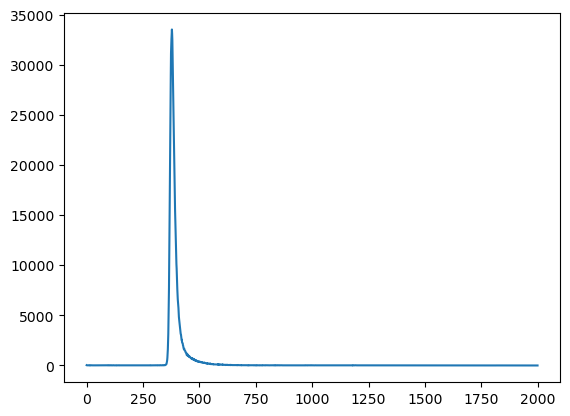

In [25]:
#init
import pymc as pm
import numpy as np
import matplotlib.pyplot as plt
import pytensor.tensor as pt
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.interpolate import splev, splrep
import os

def single(x, A, l1):
    return A * np.exp(-(l1 * x))

def conv(x,height,position,std,A,l1,B,C,l3):
    l2=(1/0.125)
    g=height*np.exp(-(x-position)**2/(2*std**2))
    e=(A * (np.exp(-(l1 * x))) + B * (np.exp(-(l2 * x))) + C * (np.exp(-(l3 * x))))# + D)
    return (np.convolve(g,e,mode='full') / sum(e) )[:667]

def gaus(x, height, position, std):
    g=height*np.exp(-(x-position)**2/(2*std**2))
    return(g)

def flat(x,D):
    y=D
    return y

#exp initial guess
iA = 1000000
il1=1/0.3
iB = 1000000
iC = 1700
il3 = 1/1.6
iD = 25

#gauss initial guess
iheight= 36651
iposition=1.2
istd=0.21

# Print the current working directory
print("Current working directory: {0}".format(os.getcwd()))

#usefull colorblind frieldly colors for the plots
CB = ['#377eb8', '#ff7f00', '#4daf4a','#f781bf', '#a65628', '#984ea3','#999999', '#e41a1c', '#dede00']

iD = 25


samples = np.loadtxt("charlies_samples.txt", dtype = str)

print(samples[0])

y = np.loadtxt(samples[0]+"_T1.dat", skiprows=4)
plt.figure()
plt.plot(y)
plt.show()

1_ns_I/230124-09-00_T1
[14.9076871]
float64 667
float64 667


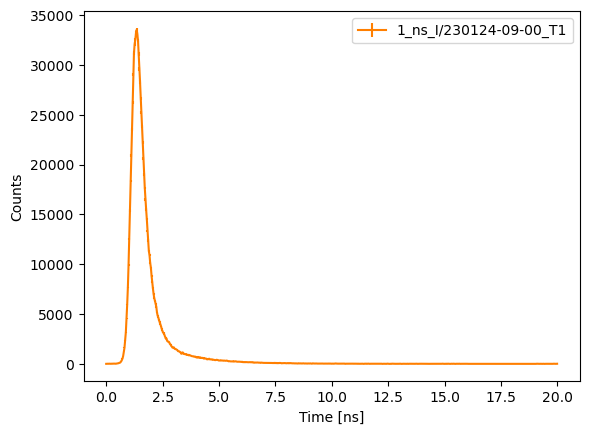

In [28]:
def plot_pals(sample):
   
    files = np.loadtxt('charlies_samples.txt',dtype=str)
    filename = files[sample] + '_T1'
    
    label = filename
    
    print(label)
    file = np.loadtxt(filename + '.dat', comments = 'S')
    a = len(file[3:])
    time = np.linspace(-10,50,a)
    N = np.zeros(a)
    for i in range(len(N)):
        N[i] = file[i+3]
    Nerr=(np.sqrt(N))
    
    #find back
    zero = 333   #fit background before rise (before zero)
    xb = time[:zero]  #only use x & y & error before zero
    yb = N[:zero] 
    Nerrb = Nerr[:zero]
    back, backpcov = curve_fit(flat,xb,yb,p0=(iD),sigma=Nerrb)  #fit flat backgound
    Nb = N-back #remove background from all y data

    print(back)
    
    #useful data
    start = 333
    stop = 1000
    y = Nb[start:stop]  #useful section of background removed y data
    x = time[start:stop] 
    #error needs to be derived from the original value for N
    ##Nerr defined at top
    Nberr=Nerr[start:stop]
    
    plt.figure('PALS histogram fit')
    plt.errorbar(x,y,yerr=Nberr,label=label,color=CB[1])
    plt.xlabel('Time [ns]')
    plt.ylabel('Counts')
    plt.legend()
    #plt.show()
    #return(float(FV), FVe, FFV3, FFV3e,label)
    return(x,y)

x,y = plot_pals(0)

print(x.dtype, x.size)
print(y.dtype, y.size)

34224.47222690367 1.3319075861291245 0.22268904520567567


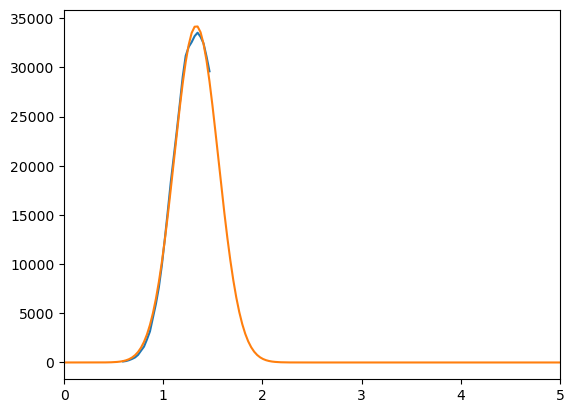

In [57]:
def fit_gaus(x,y):
    #plt.plot(x,y)
    ymaxid = np.argmax(y) + 5
    yminid = 20
    gy = y[yminid:ymaxid]
    gx = x[yminid:ymaxid]
    plt.plot(gx,gy)
    

    iheight= 36651
    iposition=1.2
    istd=0.21
    popt,pcov = curve_fit(gaus, gx,gy,p0=(iheight,iposition,istd),bounds=(0,np.inf))
    height,position,std = popt
    fity = gaus(x,height,position,std)
    plt.plot(x,fity)
    print(height,position,std)
    return(x,fity)
plt.show()
plt.xlim(0,5)
fx,fy = fit_gaus(x,y)

(5, 50000)

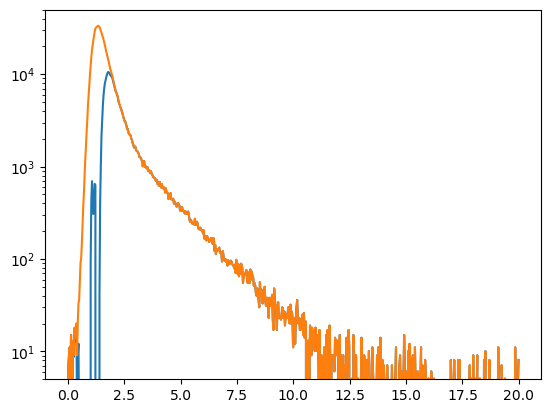

In [79]:


flaty = [y[i]-fy[i] for i in range(len(y))]
plt.semilogy(x,flaty)
plt.semilogy(x,y)
plt.ylim(5,50000)

In [24]:
import pymc as pm
import pytensor.tensor as pt
import pytensor  # <--- Import this directly
import numpy as np
import arviz as az

# 1. Setup Data (Ensure these exist in your workspace)
x_val = x.astype("float64")
y_val = y.astype("float64")
N = 667

# 2. The Convolution Function
def sliding_conv(g, e):
    # We use pytensor.scan directly from the imported module
    def step(i, g_vec, e_vec):
        return pt.dot(g_vec[:i+1], e_vec[:i+1][::-1])

    results, _ = pytensor.scan(
        fn=step,
        sequences=[pt.arange(N)],
        non_sequences=[g, e]
    )
    return results

# 3. The Model
with pm.Model() as model:
    # --- Priors centered on your Guesses ---
    # Using 'initval' ensures the sampler starts exactly where you want
    h = pm.Normal("height", mu=36651, sigma=5000, initval=36651)
    pos = pm.Normal("position", mu=1.2, sigma=0.2, initval=1.2)
    s = pm.TruncatedNormal("std", mu=0.21, sigma=0.05, lower=0.01, initval=0.21)
    
    # Large Coefficients
    A = pm.LogNormal("A", mu=np.log(1_000_000), sigma=0.5, initval=1_000_000)
    B = pm.LogNormal("B", mu=np.log(1_000_000), sigma=0.5, initval=1_000_000)
    C = pm.LogNormal("C", mu=np.log(1_700), sigma=0.5, initval=1_700)
    
    # Rates
    l1 = pm.Normal("l1", mu=1/0.3, sigma=0.5, initval=1/0.3)
    l3 = pm.Normal("l3", mu=1/1.6, sigma=0.1, initval=1/1.6)
    l2_const = 1 / 0.125
    iD_const = 25 
    
    # Observation noise
    noise = pm.HalfNormal("sigma_noise", sigma=100)

    # --- The Math ---
    g_sig = h * pt.exp(-(x_val - pos)**2 / (2 * s**2))
    e_sig = (A * pt.exp(-l1 * x_val)) + (B * pt.exp(-l2_const * x_val)) + (C * pt.exp(-l3 * x_val))
    e_norm = e_sig / pt.sum(e_sig)
    
    mu_conv = sliding_conv(g_sig, e_norm)
    mu_final = mu_conv + iD_const

    # Likelihood
    y_lik = pm.Normal("y_lik", mu=mu_final, sigma=noise, observed=y_val)

    # --- Run ---
    print("Initializing sampler at your guess coordinates...")
    # 'init="jitter+adapt_diag"' is the standard, but 'map' can be faster for tight guesses
    trace = pm.sample(draws=100, tune=100, chains=1, progressbar=True)

print("\n--- Success! ---")
print(az.summary(trace))

C:\Users\pczjo\AppData\Local\Temp\ipykernel_21364\4189290528.py:18: DeprecationWarning: Scan return signature will change. Updates dict will not be returned, only the first argument. Pass `return_updates=False` to conform to the new API and avoid this warning
  results, _ = pytensor.scan(


Initializing sampler at your guess coordinates...


c:\Users\pczjo\AppData\Local\miniconda3\envs\pymc_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [height, position, std, A, B, C, l1, l3, sigma_noise]


c:\Users\pczjo\AppData\Local\miniconda3\envs\pymc_env\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

c:\Users\pczjo\AppData\Local\miniconda3\envs\pymc_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Sampling 1 chain for 100 tune and 36 draw iterations (100 + 36 draws total) took 250 seconds.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The number of samples is too small to check convergence reliably.
arviz - WARNING - Shape validation failed: input_shape: (1, 36), minimum_shape: (chains=2, draws=4)



--- Success! ---
                    mean          sd       hdi_3%      hdi_97%   mcse_mean  \
height         36655.812       2.552    36652.349    36660.238       0.909   
position           1.273       0.004        1.266        1.279       0.001   
l1                 1.771       0.159        1.488        2.019       0.033   
l3                 0.660       0.096        0.504        0.803       0.013   
std                0.282       0.003        0.276        0.286       0.000   
A             342030.615   91086.346   188573.126   495428.060   29890.240   
B            3501912.943  843242.687  2280799.900  4795327.551  179662.999   
C               1612.625     441.853      980.841     2365.763      69.059   
sigma_noise      727.318      17.022      700.501      753.743       2.274   

                mcse_sd  ess_bulk  ess_tail  r_hat  
height            0.731       9.0      19.0    NaN  
position          0.000      22.0      17.0    NaN  
l1                0.018      24.0      41.